In [ ]:
import marimo as mo

# SimulateFactory example
This notebook demonstrates the default `SimulateFactory` workflow for
Z⁰→μ⁺μ⁻ signal and background generation, then sketches the resulting
invariant mass distributions for the prior and the smeared observations.

## Use the defaults
The first step is to import the physics helpers and instantiate a
`SimulateFactory` on CPU with its built-in settings so the example remains
reproducible across local and CI documentation builds.

In [ ]:
import matplotlib.pyplot as plt
import torch

from ttpd.generator import SimulateFactory
from ttpd.kinematics import invariant_mass_from_ptphieta, mZ0

# create simulator factory
factory = SimulateFactory.create(device=torch.device("cpu"))

Now, let's generate some signal and background prior samples.

In [ ]:
signal_theta = torch.hstack([torch.full((16, 1), mZ0), torch.zeros((16, 1))])
background_theta_1 = torch.hstack(
    [
        torch.linspace(70.0, 72.0, 4).unsqueeze(1),
        torch.ones((4, 1)),
    ]
)
background_theta_2 = torch.hstack(
    [
        torch.linspace(115.0, 118.0, 4).unsqueeze(1),
        torch.ones((4, 1)),
    ]
)
theta = torch.vstack([signal_theta, background_theta_1, background_theta_2])

## Generate events and inspect reconstructed masses

We now bootstrap the simulate function from the factory object. This has the
benefit that we can integrate useful parameters like seeds, smearing
functions, or target devices into the simulate call directly.

In [ ]:

simulate = factory.create_simulator(
    generation_seed=123, smear_seed=321, device=torch.device("cpu")
)
events = simulate(theta)
print("batch shape:", events.shape)
print("prior labels:", theta[:, 1].unique())

batch shape: torch.Size([24, 8])
prior labels: tensor([0., 1.])


The simulate function returns 4-vectors of the two decay prongs only. We can
now continue and calculate the invariant masses of the events provided.

In [ ]:
masses = invariant_mass_from_ptphieta(events)
delta = masses - theta[:, 0].unsqueeze(1)

print("first 5 reconstructed masses:", masses[:5].flatten())
print("delta mean:", delta.mean().item())

plt.close("all")

first 5 reconstructed masses: tensor([86.7119, 91.3581, 88.1780, 91.6278, 89.6038])
delta mean: -2.9704344272613525


## Compare prior and reconstructed spectra

The following plot compares the sampled parent-mass prior with the
reconstructed invariant masses obtained from the smeared decay products.

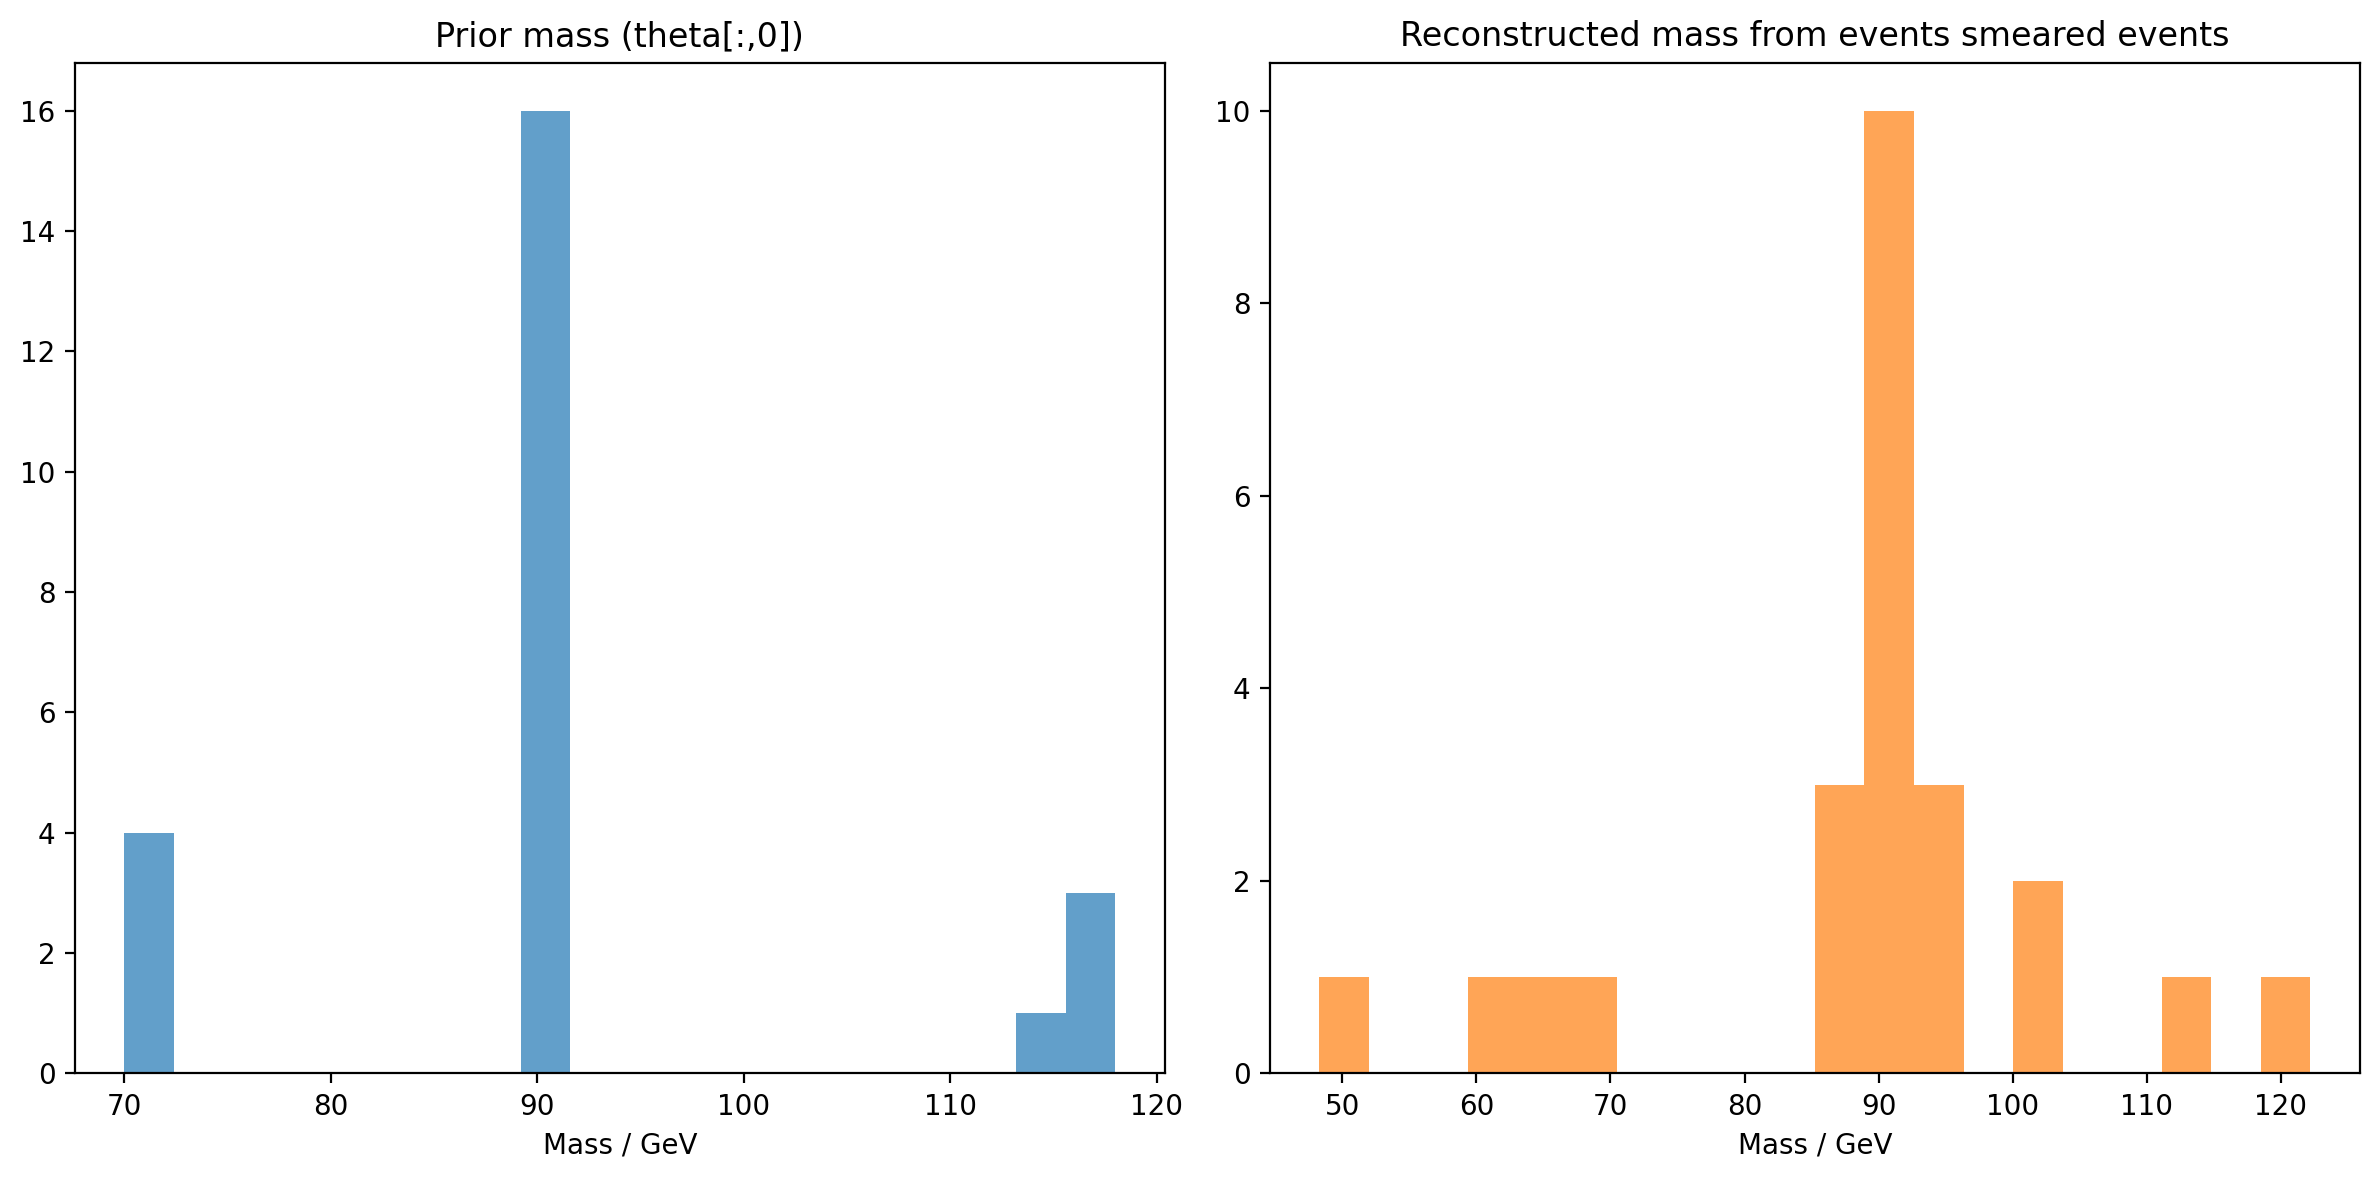

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
prior = theta[:, 0].numpy()
obs = masses.flatten().numpy()

axes[0].hist(prior, bins=20, color="tab:blue", alpha=0.7)
axes[0].set_title("Prior mass (theta[:,0])")
axes[0].set_xlabel("Mass / GeV")

axes[1].hist(obs, bins=20, color="tab:orange", alpha=0.7)
axes[1].set_title("Reconstructed mass from events smeared events")
axes[1].set_xlabel("Mass / GeV")

fig

## More real world generation

In the cell below, we generate a set of signal events and one background
channel only. For each channel, we select a distribution of mass values,
but have to assign the channel ID by virtue of an integer (`0` for signal,
`1` for background).

In [ ]:
# prepare channel id
num_signal = 5_000
num_backgd = 1_000
theta_ids = torch.concat(
    [torch.zeros((num_signal, 1)), torch.ones((num_backgd, 1))]
)

# prepare pdf or prior for each channel
signal_pdf = torch.distributions.Cauchy(loc=mZ0, scale=0.05)
backgd_pdf = torch.distributions.Uniform(mZ0 - 30, mZ0 + 30)
theta_masses = torch.concat(
    [signal_pdf.sample((num_signal, 1)), backgd_pdf.sample((num_backgd, 1))]
)

# join everything into one tensor
thetas = torch.hstack([theta_masses, theta_ids])

In [ ]:
# what it looks like
print(
    f"created simulation parameter samples of shape {thetas.shape}\n"
    f"and type {thetas.dtype}\n"
)
print(f"the first entries contain signal 'events'\n{thetas[:5, ...]}")
print(f"the last entries contain background 'events'\n{thetas[-5:, ...]}")

created simulation parameter samples of shape torch.Size([6000, 2])
and type torch.float32

the first entries contain signal 'events'
tensor([[91.1068,  0.0000],
        [90.2529,  0.0000],
        [90.4804,  0.0000],
        [90.9311,  0.0000],
        [91.1525,  0.0000]])
the last entries contain background 'events'
tensor([[ 84.0005,   1.0000],
        [ 95.3752,   1.0000],
        [ 81.6930,   1.0000],
        [116.8473,   1.0000],
        [ 71.1955,   1.0000]])


Now, we can go forward and generate some observations `xs`.

In [ ]:
# let's simulate
xs = simulate(thetas)

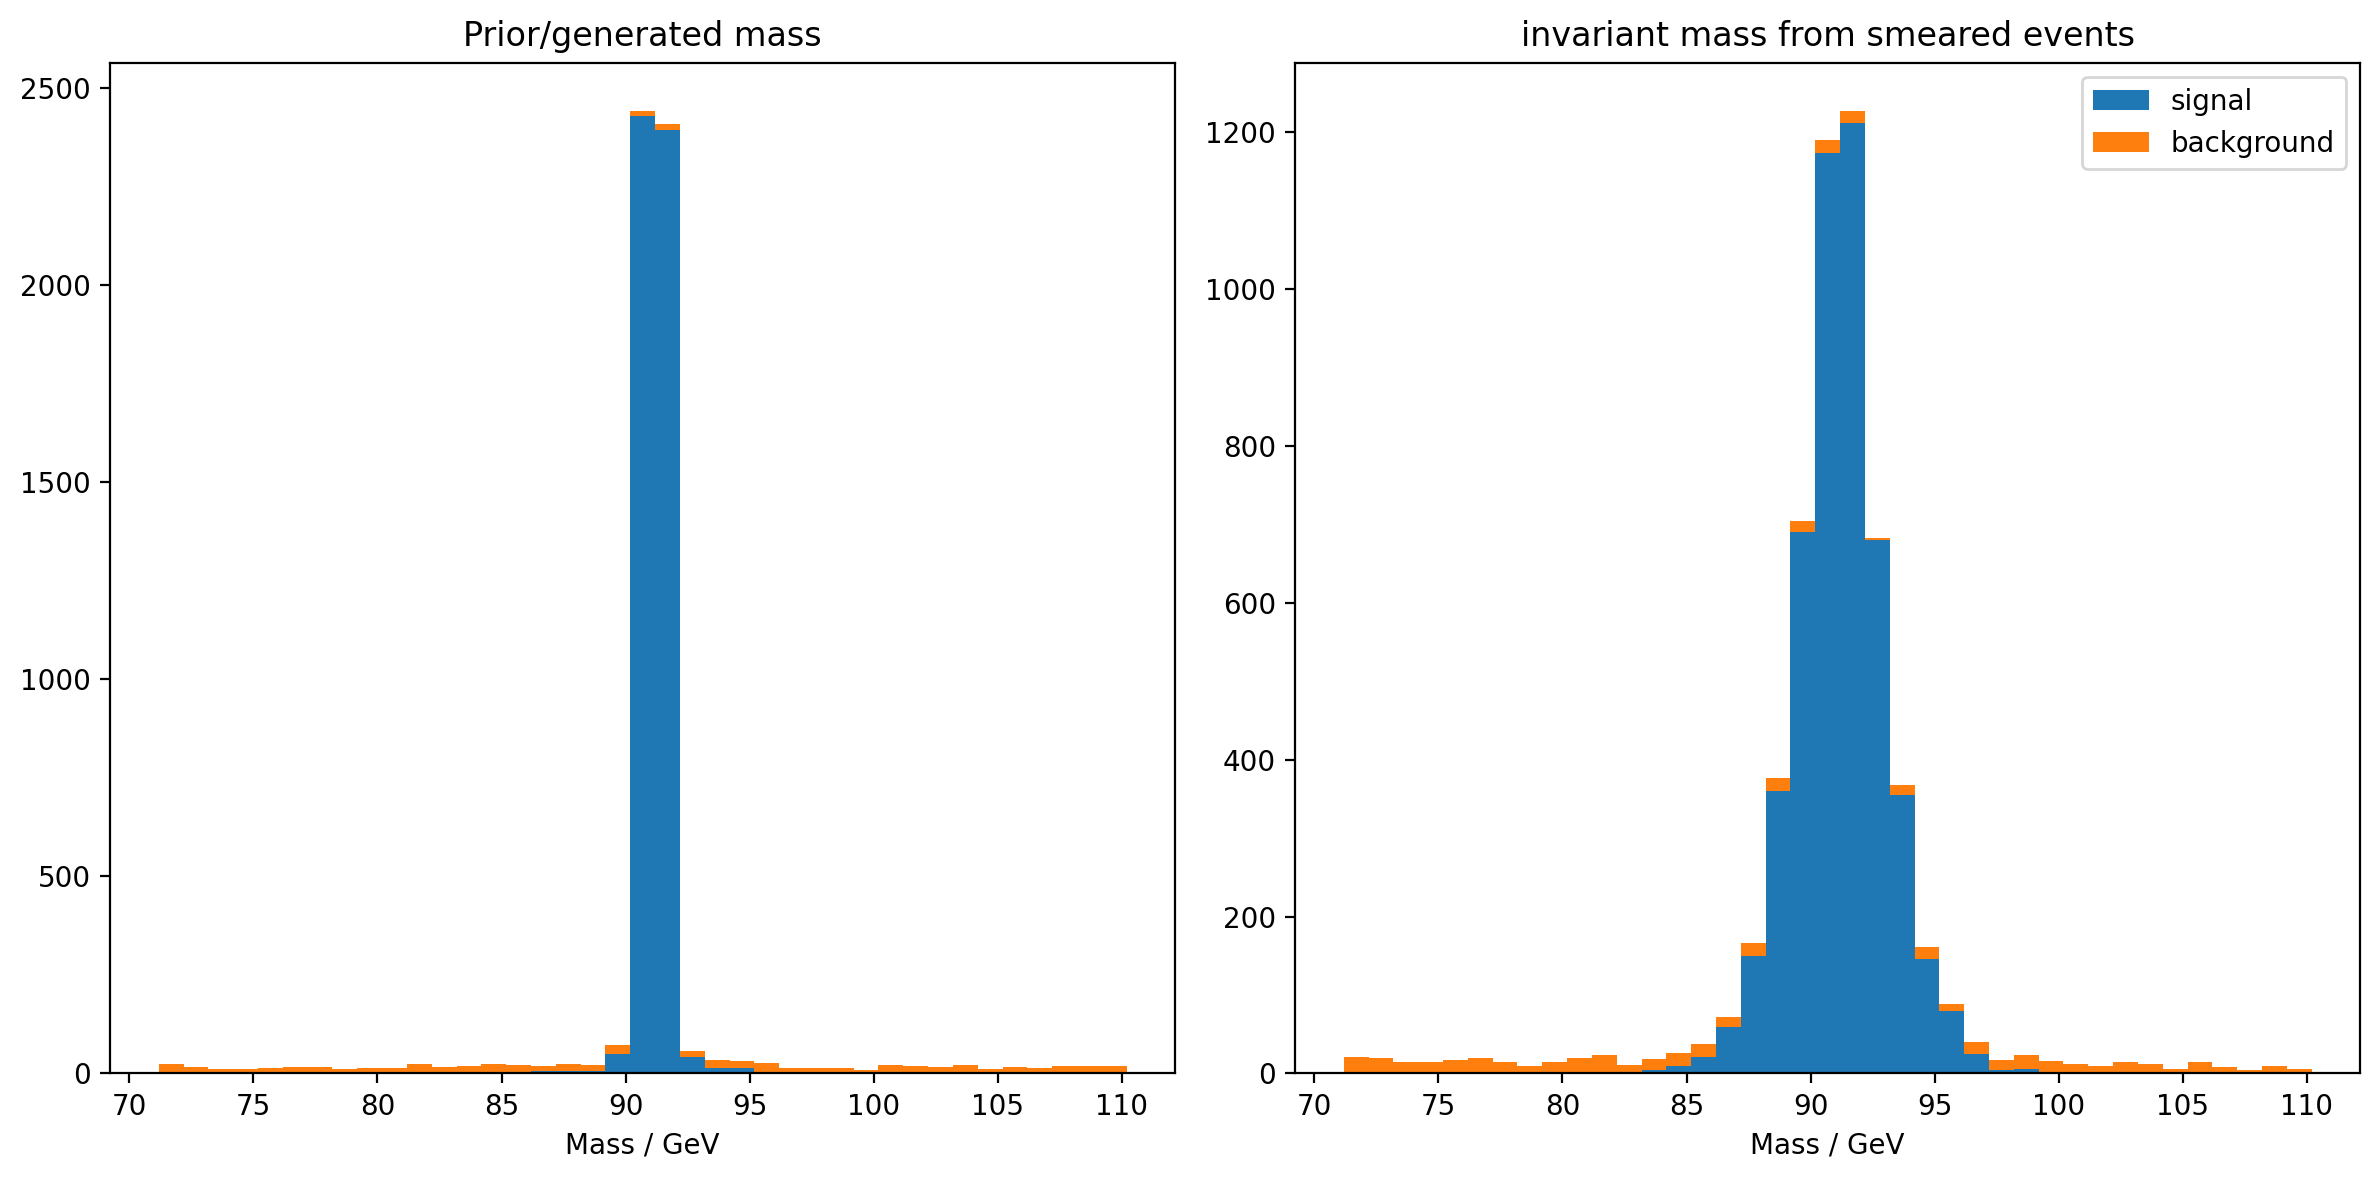

In [ ]:
# let's inspect
figa, axesa = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
masses_ = invariant_mass_from_ptphieta(xs)

axesa[0].hist(
    [thetas[:num_signal, 0], thetas[-num_backgd:, 0]],
    bins=torch.arange(mZ0 - 20, mZ0 + 20, 1),
    stacked=True,
    label=["signal", "background"],
)
axesa[0].set_title("Prior/generated mass")
axesa[0].set_xlabel("Mass / GeV")

axesa[1].hist(
    [masses_[:num_signal, 0], masses_[-num_backgd:, 0]],
    bins=torch.arange(mZ0 - 20, mZ0 + 20, 1),
    stacked=True,
    label=["signal", "background"],
)
axesa[1].set_title("invariant mass from smeared events")
axesa[1].set_xlabel("Mass / GeV")
axesa[1].legend()
figa

The above plot shows the generated samples (left) and smeared +
reconstructed on the right. We see that the cauchy distribution has become
wider as we smeared the kinematics of the decay products.